## Why are the Guardians always better than expected? An exploration of relief pitcher value by a frustrated fan of a different AL Central team

# Introduction
Every year, many analysts use advanced stats to predict the outcomes of the upcoming season. In particular, baseball has a rich ecosystem of advanced stats, both due to its large sample sizes and the relative ease of assigning specific outcomes to individual players. Over the past few years, my favorite MLB team, the Minnesota Twins, has often been picked to finish first in their division by analytics-based forecasts. Anecdotally, it feels like the Cleveland Guardians, one of the Twins' division rivals, outperfrom their expectations, either making the division race closer than expected or outright beating the Twins. During the 2024 season, the Guardians continued to score and allow runs at rates that suggested they shouldn't keep up their division-leading pace... but they did anyway.

# A brief note on WAR, and why I'm studying relief pitchers
Wins Above Replacement, abbreviated WAR, is an all-encompassing statistic meant to quantify how many wins a player is worth to his team relative to a "replacement player." This replacement level is defined as the average level of a player who would get called up to the major leagues in the event of an injury- for instance, if I were a major league player worth 3.0 WAR over the 2024 season, my team would be expected to win 3 more games with me than they would have if I suddenly retired and decided not to play before the season started. There is no single agreed-upon formula for WAR yet, but the two most prominent public-facing versions of WAR are published by the websites Fangraphs and Baseball Reference. These two sites' WAR totals often differ slightly for specific players, but are usually in the same ballpark as each other (pun intended).

Because it's well-accepted that "clutch" hitting and pitching isn't sustainable over time in baseball, WAR is computed based on individual plays and largely doesn't take game situations into account. If I hit a single against a specific pitcher, it would have the same effect on my WAR if it occurred in a tied game as it would in a blowout. WAR is computed first by computing the number of expected runs a player is worth relative to a replacement player, and this is divided by a factor of approximately 10 (this varies slightly year-to-year for a variety of reasons) to get WAR.

After the Guardians won games at a seemingly unsustainable rate last year, I had a realization about the assumptions underlying WAR. The context-neutral computation of WAR works well for hitters who play most of the time. It also works well for starting pitchers, who pitch on a pre-scheduled rotation and ideally pitch the majority of the games they appear in. But the usage of relievers isn't context-neutral. Teams use their best relievers in the situations where a run is most likely to swing the outcome of a game. And while the Guardians were winning at a seemingly unsustainable rate, their star reliever, Emmanuel Clase, was having one of the best seasons a relief pitcher has had in recent memory. Because of Clase's performance, I started to wonder if there is a better way to classify the value of a star reliever to his team.

# Methodology
WAR is closely related to the stat Wins Above Average (WAA); WAA uses an average major leaguer as a baseline instead of a replacement-level player and is also context-neutral like WAR. In fact, the difference between WAR and WAA is simply the number of wins an average player would be worth over replacement; this term varies only based on the amount of playing time a player gets.

Win Probability Added (WPA) represents the effect a player's actions have on his team winning a game, and is very context-dependent. Since the usage of relievers is itself context-dependent, I plan to replace the WAA portion of WAR with a player's WPA to get an adjusted, probability-based WAR for relievers.

Currently, I'm using two sources for data. The Python package pybaseball contains an API to download data from Fangraphs, and this data includes WPA and the Fangraphs version of WAR (known as fWAR), but it does not have WAA. I also downloaded a .csv file directly from Baseball Reference's data repository, and this file contains the Baseball Reference version of WAR (known as bWAR or sometimes rWAR) and WAA, but not WPA. Baseball Reference does compute WPA on players' pages, but this data does not appear to be present in the download.

I first show that there is a non-linear polynomial relationship between WAA and WPA which suggests that WAA (and therefore also WAR) undervalues elite relievers.

# Future directions
After computing this adjusted probability-based WAR (which I call pWAR in this notebook), I plan to see whether it better predicts a team's performance than the standard versions of WAR. I will check both with players' actual WPA and by computing a version of pWAR which uses the polynomial regression relationship between WAA and WPA instead of a player's actual WPA. Since WPA is a relatively volatile stat, this second version of pWAR may have potential use for prediction modeling of future games even if it is outperformed by the first version of pWAR for past games.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pybaseball as pyb
import unidecode

/Users/andrewford/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
# These files were downloaded from https://www.baseball-reference.com/data/ - you'll have to do the same and update the paths to replicate the results.
# These files are updated daily, but I'm not using the partially completed 2025 season.
pitcher_filename_bref = "/Users/andrewford/Downloads/war_archive-2025-06-29/war_daily_pitch.txt"
batter_filename_bref = "/Users/andrewford/Downloads/war_archive-2025-06-29/war_daily_bat.txt"

In [4]:
pitcher_data_bref = pd.read_csv(pitcher_filename_bref)

In [5]:
print(pitcher_data_bref.describe())

                age         mlb_ID       year_ID      stint_ID             G  \
count  56136.000000   56527.000000  56602.000000  56602.000000  56602.000000   
mean      27.748504  280605.566561   1974.092241      1.039416     22.188509   
std        4.419419  233951.984324     39.620135      0.379066     18.473817   
min       15.000000  110003.000000   1871.000000      0.000000      0.000000   
25%       25.000000  116147.500000   1942.000000      1.000000      6.000000   
50%       27.000000  121981.000000   1984.000000      1.000000     19.000000   
75%       30.000000  459939.000000   2008.000000      1.000000     34.000000   
max       58.000000  820862.000000   2025.000000      5.000000    106.000000   

                 GS        IPouts  IPouts_start  IPouts_relief            RA  \
count  56602.000000  56602.000000  50383.000000   50383.000000  56602.000000   
mean       8.503233    227.117929    164.460493      60.577496     38.759655   
std       11.667197    243.337227    23

In [6]:
list(pitcher_data_bref.columns)

['name_common',
 'age',
 'mlb_ID',
 'player_ID',
 'year_ID',
 'team_ID',
 'stint_ID',
 'lg_ID',
 'G',
 'GS',
 'IPouts',
 'IPouts_start',
 'IPouts_relief',
 'RA',
 'xRA',
 'xRA_sprp_adj',
 'xRA_extras_adj',
 'xRA_def_pitcher',
 'PPF',
 'PPF_custom',
 'xRA_final',
 'BIP',
 'BIP_perc',
 'RS_def_total',
 'runs_above_avg',
 'runs_above_avg_adj',
 'runs_above_rep',
 'RpO_replacement',
 'GR_leverage_index_avg',
 'WAR',
 'salary',
 'teamRpG',
 'oppRpG',
 'pyth_exponent',
 'waa_win_perc',
 'WAA',
 'WAA_adj',
 'oppRpG_rep',
 'pyth_exponent_rep',
 'waa_win_perc_rep',
 'WAR_rep',
 'ERA_plus',
 'ER_lg']

In [9]:
start_year = 2010
end_year = 2024
pitcher_data_yrs = pitcher_data_bref[pitcher_data_bref['year_ID'] >= start_year]
pitcher_data_yrs = pitcher_data_yrs[pitcher_data_yrs['year_ID'] <= end_year]

In [11]:
# Replaced with average length of outing < 2 innings to account for games with openers
#pitcher_data_relievers = pitcher_data_yrs[pitcher_data_yrs['IPouts_relief'] > pitcher_data_yrs['IPouts_start']]
pitcher_data_relievers_bref = pitcher_data_yrs[pitcher_data_yrs['IPouts']/pitcher_data_yrs['G'] < 6]

In [12]:
pitcher_data_relievers_bref.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G,GS,...,pyth_exponent,waa_win_perc,WAA,WAA_adj,oppRpG_rep,pyth_exponent_rep,waa_win_perc_rep,WAR_rep,ERA_plus,ER_lg
43207,David Aardsma,28.0,430911.0,aardsda01,2010,SEA,1,AL,53,0,...,1.862,0.5033,0.1749,-0.0282,4.54436,1.870,0.4899,0.5309,115.168421,21.882
43208,Jeremy Accardo,28.0,435618.0,accarje01,2010,TOR,1,AL,5,0,...,1.897,0.4433,-0.2835,-0.0219,4.58560,1.872,0.4856,0.0714,54.466667,3.268
43209,Alfredo Aceves,27.0,469686.0,aceveal01,2010,NYY,1,AL,10,0,...,1.864,0.5011,0.0110,-0.0278,4.57172,1.872,0.4870,0.1289,147.825000,5.913
43210,Jonathan Albaladejo,27.0,452293.0,albaljo01,2010,NYY,1,AL,10,0,...,1.862,0.5042,0.0420,-0.0409,4.56479,1.871,0.4878,0.1210,111.880000,5.594
43211,Matt Albers,27.0,458006.0,alberma01,2010,BAL,1,AL,62,0,...,1.867,0.4949,-0.3162,-0.1644,4.57385,1.872,0.4868,0.8117,92.076316,34.989
43212,Héctor Ambriz,26.0,459932.0,ambrihe01,2010,CLE,1,AL,34,0,...,1.880,0.4719,-0.9554,0.1392,4.59478,1.873,0.4847,0.5159,70.996667,21.299
43215,Scott Atchison,34.0,425786.0,atchisc01,2010,BOS,1,AL,43,1,...,1.875,0.4812,-0.8084,-0.1387,4.59205,1.873,0.4850,0.6397,97.200000,29.160
43216,Andrew Bailey,26.0,457732.0,bailean01,2010,OAK,1,AL,47,0,...,1.849,0.5272,1.2784,0.3320,4.55534,1.871,0.4887,0.5268,281.150000,22.492
43218,Grant Balfour,32.0,346797.0,balfogr01,2010,TBR,1,AL,57,0,...,1.858,0.5114,0.6498,-0.0674,4.54787,1.870,0.4895,0.5936,172.171429,24.104
43220,Daniel Bard,25.0,453268.0,bardda01,2010,BOS,1,AL,73,0,...,1.851,0.5236,1.7228,0.6038,4.55329,1.871,0.4889,0.8037,226.537500,36.246


In [13]:
pitching_data_fg = pyb.pitching_stats(start_season=start_year, end_season=end_year, qual=0)
print(pitching_data_fg.shape)
pitching_data_fg.head(10)

(11425, 393)


,IDfg,Season,Name,Team,Age,W,L,WAR,ERA,G,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
842,10954,2018,Jacob deGrom,NYM,30,10,9,9.0,1.70,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1441,1303,2011,Roy Halladay,PHI,34,19,6,8.7,2.35,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1165,2036,2015,Clayton Kershaw,LAD,27,16,7,8.6,2.13,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,2036,2014,Clayton Kershaw,LAD,26,21,3,7.9,1.77,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2315,10603,2017,Chris Sale,BOS,28,17,8,7.6,2.90,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1642,13125,2019,Gerrit Cole,HOU,28,20,5,7.5,2.50,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1664,3137,2018,Max Scherzer,WSN,33,18,7,7.5,2.53,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1512,19361,2021,Corbin Burnes,MIL,26,11,5,7.5,2.43,28,...,140.0,NaN,NaN,NaN,132.0,99.0,128.0,NaN,NaN,NaN
1342,2036,2011,Clayton Kershaw,LAD,23,21,5,7.3,2.28,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2946,1636,2010,Cliff Lee,- - -,31,12,9,7.3,3.18,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
column_list = ['IDfg','Season','Name','Team','IP','Starting','Start-IP','Relieving','Relief-IP','WPA','+WPA','-WPA','RE24','REW','WPA/LI','WAR','G','GS']
pitching_data_wins_fg = pitching_data_fg[column_list]
pitching_data_wins_fg.head(10)

,IDfg,Season,Name,Team,IP,Starting,Start-IP,Relieving,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,WAR,G,GS
842,10954,2018,Jacob deGrom,NYM,217.0,75.8,217.0,NaN,NaN,5.85,18.48,-12.63,52.57,5.70,4.62,9.0,32,32
1441,1303,2011,Roy Halladay,PHI,233.2,71.7,233.2,NaN,NaN,4.41,19.04,-14.63,44.83,4.88,3.82,8.7,32,32
1165,2036,2015,Clayton Kershaw,LAD,232.2,70.8,232.2,NaN,NaN,4.98,16.30,-11.32,46.05,5.21,5.67,8.6,33,33
884,2036,2014,Clayton Kershaw,LAD,198.1,62.5,198.1,NaN,NaN,5.04,14.74,-9.69,43.95,4.92,4.97,7.9,27,27
2315,10603,2017,Chris Sale,BOS,214.1,68.9,214.1,NaN,NaN,3.73,16.09,-12.36,38.99,3.83,4.09,7.6,32,32
1642,13125,2019,Gerrit Cole,HOU,212.1,70.1,212.1,NaN,NaN,4.31,14.72,-10.41,49.91,4.94,5.13,7.5,33,33
1664,3137,2018,Max Scherzer,WSN,220.2,65.0,220.2,NaN,NaN,4.84,15.70,-10.86,42.84,4.42,4.74,7.5,33,33
1512,19361,2021,Corbin Burnes,MIL,167.0,65.3,167.0,NaN,NaN,3.31,12.49,-9.18,34.93,3.55,4.44,7.5,28,28
1342,2036,2011,Clayton Kershaw,LAD,233.1,62.2,233.1,NaN,NaN,3.57,16.96,-13.39,35.49,4.16,4.21,7.3,33,33
2946,1636,2010,Cliff Lee,- - -,212.1,63.2,211.4,NaN,NaN,2.17,14.94,-12.78,21.67,2.19,3.31,7.3,28,28


In [ ]:
relief_pitching_data_fg = pitching_data_wins_fg[pitching_data_wins_fg["IP"]/pitching_data_wins_fg["G"] < 2.0]
#relief_pitching_data.head(10)
relief_pitching_data_fg[relief_pitching_data_fg["Name"] == 'Jhoan Duran']
# Note when combining names, the Fangraphs data doesn't have accents in names


,IDfg,Season,Name,Team,IP,Starting,Start-IP,Relieving,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,WAR,G,GS
958,21029,2022,Jhoan Duran,MIN,67.2,NaN,NaN,14.3,67.2,4.56,8.90,-4.34,20.08,2.19,1.59,1.5,57,0
4101,21029,2024,Jhoan Duran,MIN,54.1,NaN,NaN,11.5,54.1,1.53,8.82,-7.29,-1.21,-0.12,0.13,1.2,58,0
1549,21029,2023,Jhoan Duran,MIN,62.1,NaN,NaN,10.7,62.1,2.01,10.47,-8.46,14.15,1.42,1.26,1.1,59,0


In [20]:
#del pitcher_data_bref
#del pitcher_data_yrs
#del pitching_data_fg
#del pitching_data_full
#del rpd_sorted
del relief_pitching_data
#del relief_pitching_data_2

In [ ]:
# Added an ascii version of the name to match the name field from the Fangraphs data
pitcher_data_relievers_bref['name_ascii'] = pitcher_data_relievers_bref['name_common'].apply(unidecode.unidecode)
pitcher_data_relievers_bref[pitcher_data_relievers_bref['name_common'] == 'Jhoan Durán']

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G,GS,...,waa_win_perc,WAA,WAA_adj,oppRpG_rep,pyth_exponent_rep,waa_win_perc_rep,WAR_rep,ERA_plus,ER_lg,name_ascii
53045,Jhoan Durán,24.0,661395.0,duranjh01,2022,MIN,1,AL,57,0,...,0.5319,1.8183,0.3719,4.35751,1.847,0.4885,0.6582,209.757143,29.366,Jhoan Duran
54019,Jhoan Durán,25.0,661395.0,duranjh01,2023,MIN,1,AL,59,0,...,0.5186,1.0974,0.2616,4.70821,1.889,0.4898,0.6047,178.870588,30.408,Jhoan Duran
54997,Jhoan Durán,26.0,661395.0,duranjh01,2024,MIN,1,AL,58,0,...,0.4970,-0.1740,-0.1898,4.46877,1.862,0.4911,0.5295,115.490909,25.408,Jhoan Duran


In [29]:
pitcher_data_relievers_bref.sort_values(by=['name_common', 'year_ID'],ascending = False)
relief_pitching_data_fg.sort_values(by=['Name', 'Season'], ascending = False)
print(pitcher_data_relievers_bref.head())
print(relief_pitching_data_fg.head())

               name_common   age    mlb_ID  player_ID  year_ID team_ID  \
43207        David Aardsma  28.0  430911.0  aardsda01     2010     SEA   
43208       Jeremy Accardo  28.0  435618.0  accarje01     2010     TOR   
43209       Alfredo Aceves  27.0  469686.0  aceveal01     2010     NYY   
43210  Jonathan Albaladejo  27.0  452293.0  albaljo01     2010     NYY   
43211          Matt Albers  27.0  458006.0  alberma01     2010     BAL   

       stint_ID lg_ID   G  GS  ...  waa_win_perc     WAA  WAA_adj  oppRpG_rep  \
43207         1    AL  53   0  ...        0.5033  0.1749  -0.0282     4.54436   
43208         1    AL   5   0  ...        0.4433 -0.2835  -0.0219     4.58560   
43209         1    AL  10   0  ...        0.5011  0.0110  -0.0278     4.57172   
43210         1    AL  10   0  ...        0.5042  0.0420  -0.0409     4.56479   
43211         1    AL  62   0  ...        0.4949 -0.3162  -0.1644     4.57385   

       pyth_exponent_rep  waa_win_perc_rep  WAR_rep    ERA_plus   ER

In [81]:
print(relief_pitching_data_fg['Team'].unique())

['OAK' 'SEA' 'LAD' 'SDP' 'BOS' 'CIN' 'KCR' 'ATL' 'NYY' 'NYM' '- - -' 'TOR'
 'MIA' 'BAL' 'MIL' 'CHW' 'CLE' 'CHC' 'STL' 'MIN' 'TEX' 'TBR' 'PIT' 'SFG'
 'HOU' 'PHI' 'LAA' 'COL' 'ARI' 'WSN' 'DET' 'FLA']


In [82]:
combined_pitching_data = pd.merge(pitcher_data_relievers_bref, relief_pitching_data_fg, left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
# this is a temporary workaround for fitting the model- removes players who played for multiple teams because WPA is combined for the whole season for them and bWAR isn't
combined_pitching_data_single_team = pd.merge(pitcher_data_relievers_bref, relief_pitching_data_fg[relief_pitching_data_fg['Team'] != '- - -'], left_on=['name_ascii', 'year_ID'], right_on=['Name', 'Season'], how='inner')
combined_columns = ['name_common', 'year_ID', 'WAR_x', 'WAA', 'WAA_adj', 'Name', 'Season', 'WAR_y', 'WPA', '+WPA', '-WPA']
print(combined_pitching_data[combined_columns].head())
print(combined_pitching_data_single_team[combined_columns].head())


           name_common  year_ID  WAR_x     WAA  WAA_adj                 Name  \
0        David Aardsma     2010   0.68  0.1749  -0.0282        David Aardsma   
1       Jeremy Accardo     2010  -0.23 -0.2835  -0.0219       Jeremy Accardo   
2       Alfredo Aceves     2010   0.11  0.0110  -0.0278       Alfredo Aceves   
3  Jonathan Albaladejo     2010   0.12  0.0420  -0.0409  Jonathan Albaladejo   
4          Matt Albers     2010   0.33 -0.3162  -0.1644          Matt Albers   

   Season  WAR_y   WPA  +WPA  -WPA  
0    2010    0.3  0.23  8.10 -7.87  
1    2010    0.1 -0.43  0.51 -0.94  
2    2010    0.0  0.46  0.87 -0.41  
3    2010   -0.1 -0.03  0.17 -0.21  
4    2010    0.0  0.33  4.20 -3.87  
           name_common  year_ID  WAR_x     WAA  WAA_adj                 Name  \
0        David Aardsma     2010   0.68  0.1749  -0.0282        David Aardsma   
1       Jeremy Accardo     2010  -0.23 -0.2835  -0.0219       Jeremy Accardo   
2       Alfredo Aceves     2010   0.11  0.0110  -0.0278  

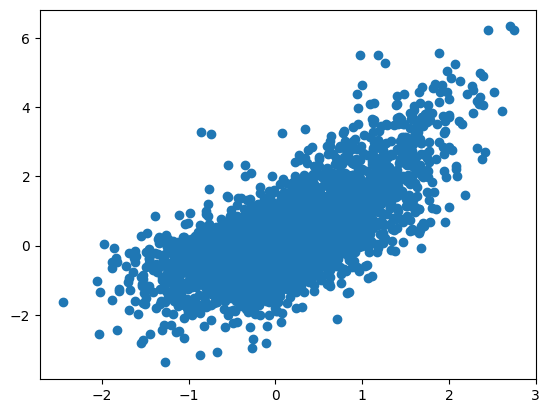

In [83]:
plt.scatter(combined_pitching_data_single_team['WAA'], combined_pitching_data_single_team['WPA'])
plt.show()

In [84]:
# renaming columns to clarify which type of WAR is represented
combined_pitching_data = combined_pitching_data.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})
combined_pitching_data_single_team = combined_pitching_data_single_team.rename(columns={'WAR_x': 'bWAR', 'WAR_y': 'fWAR'})

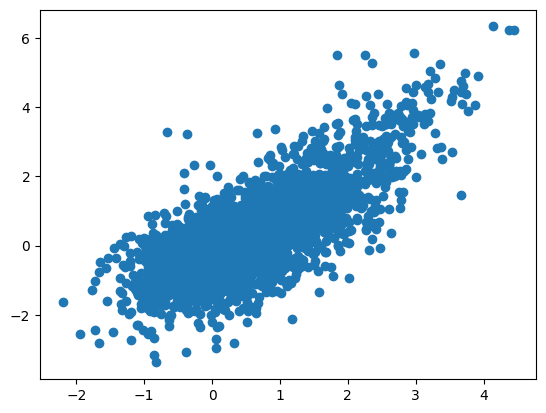

In [85]:
# Retroactively changed WAR_x to bWAR because I did that in a later cell
plt.scatter(combined_pitching_data_single_team['bWAR'], combined_pitching_data_single_team['WPA'])
plt.show()

In [86]:
print(f"Full dataset shape: {combined_pitching_data.shape}")
print(f"Single team dataset shape: {combined_pitching_data_single_team.shape}")

Full dataset shape: (7666, 62)
Single team dataset shape: (6152, 62)


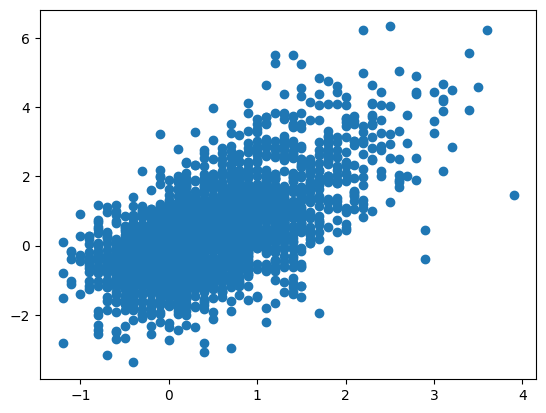

In [87]:
# Retroactively changed WAR_y to fWAR because I did that in a later cell
plt.scatter(combined_pitching_data_single_team['fWAR'], combined_pitching_data_single_team['WPA'])
plt.show()

In [88]:
combined_pitching_data.sort_values(by=['WPA'], ascending=False, inplace=True)

In [89]:
combined_pitching_data.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G_x,GS_x,...,Relief-IP,WPA,+WPA,-WPA,RE24,REW,WPA/LI,fWAR,G_y,GS_y
2587,Zack Britton,28.0,502154.0,brittza01,2016,BAL,1,AL,69,0,...,67.0,6.33,9.96,-3.63,30.89,3.13,2.57,2.5,69,0
7122,Emmanuel Clase,26.0,661403.0,claseem01,2024,CLE,1,AL,74,0,...,74.1,6.23,10.42,-4.19,30.26,3.18,2.97,2.2,74,0
3794,Blake Treinen,30.0,595014.0,treinbl01,2018,OAK,1,AL,68,0,...,80.1,6.22,13.67,-7.45,27.11,2.78,2.57,3.6,68,0
3402,Kenley Jansen,29.0,445276.0,janseke01,2017,LAD,1,NL,65,0,...,68.1,5.57,9.51,-3.94,22.20,2.27,2.45,3.4,65,0
2471,Mark Melancon,30.0,453343.0,melanma01,2015,PIT,1,NL,78,0,...,76.2,5.52,11.64,-6.12,16.44,1.75,1.95,1.4,78,0
4649,Will Smith,29.0,519293.0,smithwi04,2019,SFG,1,NL,63,0,...,65.1,5.50,10.64,-5.14,15.07,1.56,1.62,1.2,63,0
908,Jim Johnson,29.0,462382.0,johnsji04,2012,BAL,1,AL,71,0,...,68.2,5.27,10.94,-5.67,12.49,1.29,2.15,1.2,71,0
650,Tyler Clippard,26.0,461325.0,clippty01,2011,WSN,1,NL,72,0,...,88.1,5.26,10.68,-5.42,28.18,3.06,1.93,1.5,72,0
2702,Andrew Miller,31.0,453192.0,millean01,2016,NYY,1,AL,44,0,...,74.1,5.07,9.91,-4.84,24.82,2.50,2.71,2.9,70,0
2703,Andrew Miller,31.0,453192.0,millean01,2016,CLE,2,AL,26,0,...,74.1,5.07,9.91,-4.84,24.82,2.50,2.71,2.9,70,0


In [39]:
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [90]:
X = np.array(combined_pitching_data_single_team['WAA']).reshape(-1,1)
y = np.array(combined_pitching_data_single_team['WPA']).reshape(-1,1)

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
regr = LinearRegression()
regr.fit(X_train, y_train)
print("Coefficients: ", regr.coef_)
print("Intercept: ", regr.intercept_)
print(regr.score(X_test, y_test))

Coefficients:  [[1.09507077]]
Intercept:  [0.13397168]
0.47033246138052975


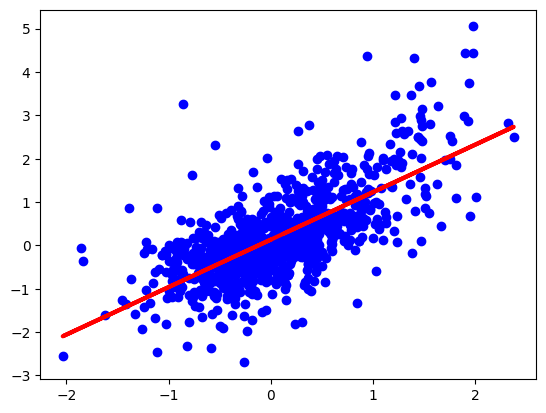

In [92]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=3)

It looks like this isn't a perfect linear fit- at the high end, WPA is higher than WAA alone would suggest. I believe this means the effect of leverage is not considered strongly enough to reflect elite relievers' actual effect on performance.

In [43]:
from sklearn.metrics import PredictionErrorDisplay

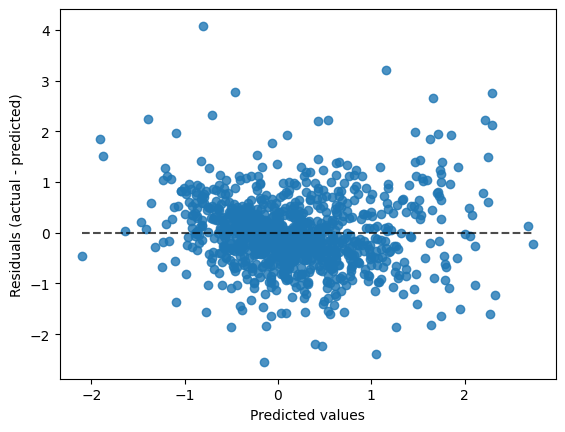

In [93]:
display = PredictionErrorDisplay(y_true=y_test, y_pred=y_pred)
display.plot()
plt.show()

In [45]:
# try a quadratic fit?
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2)
poly_regr = LinearRegression()
poly_regr.fit(X_train_poly, y_train_poly)
print("Coefficients: ", poly_regr.coef_)
print("Intercept: ", poly_regr.intercept_)
print(poly_regr.score(X_test_poly, y_test_poly))

Coefficients:  [[0.         0.97508188 0.31093726]]
Intercept:  [0.00772196]
0.5012362721324201


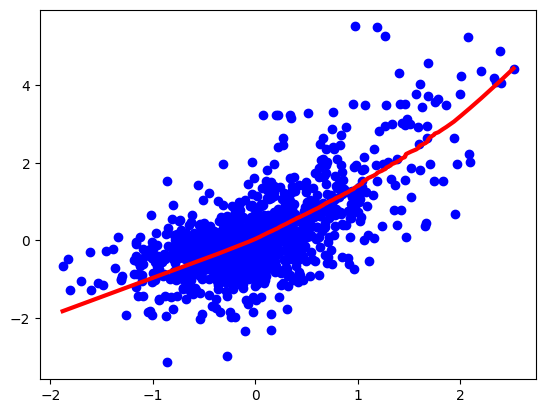

In [49]:
X_test_poly_sorted = np.sort(X_test_poly, axis=0)
y_pred_poly = poly_regr.predict(X_test_poly)
y_pred_poly_sorted = poly_regr.predict(X_test_poly_sorted)
plt.scatter(X_test_poly[:,1], y_test_poly, color='blue')
plt.plot(X_test_poly_sorted[:,1], y_pred_poly_sorted, color='red', linewidth=3)

In [50]:
print(X_test_poly.shape)
print(y_test_poly.shape)

(1534, 3)
(1534, 1)


In [51]:
print(X_test_poly)

[[ 1.          0.0501      0.00251001]
 [ 1.         -1.1606      1.34699236]
 [ 1.         -0.8024      0.64384576]
 ...
 [ 1.          0.308       0.094864  ]
 [ 1.         -0.1485      0.02205225]
 [ 1.         -0.9639      0.92910321]]


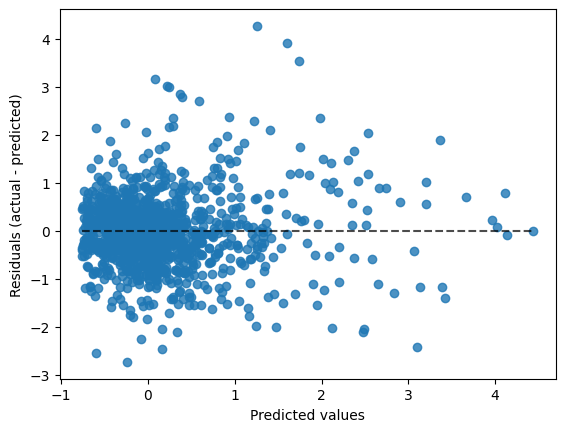

In [52]:
display = PredictionErrorDisplay(y_true=y_test_poly, y_pred=y_pred_poly)
display.plot()
plt.show()

In [98]:
print(combined_pitching_data_single_team[combined_pitching_data_single_team['WPA']-combined_pitching_data_single_team['WAA'] > 3][['name_common','year_ID','team_ID', 'WPA', 'WAA']])

         name_common  year_ID team_ID   WPA     WAA
133   Rafael Soriano     2010     TBR  4.09  1.0880
174       Heath Bell     2010     SDP  4.63  0.9983
557   Tyler Clippard     2011     WSN  5.26  2.0736
781      Jim Johnson     2012     BAL  5.27  1.2638
1120  Ernesto Frieri     2013     LAA  3.24  0.0737
1411    Brad Ziegler     2013     ARI  3.98  0.9516
2089     Seth Maness     2015     STL  3.27 -0.8588
2101   Mark Melancon     2015     PIT  5.52  0.9750
2197    Zack Britton     2016     BAL  6.33  2.7048
2748     Ryan Tepera     2017     TOR  3.37  0.3431
2852   Kenley Jansen     2017     LAD  5.57  1.8850
3141   Blake Treinen     2018     OAK  6.22  2.4480
3804      Will Smith     2019     SFG  5.50  1.1844
4632      Josh Hader     2021     MIL  5.05  1.9740
5549     Alexis Díaz     2023     CIN  4.37  0.9372
5757  Emmanuel Clase     2024     CLE  6.23  2.7454
6034    Tyler Kinley     2024     COL  3.22 -0.7437


Some of the players in the table above seemed to have incredible luck in some years. For instance, in 2024, Tyler Kinley had a pretty bad ERA overall, but wasn't charged with any runs (earned or unearned) in his 17 highest-leverage appearances. This generally isn't repeatable.

Degree 1 - Coefficients:  [[0.         1.09736692]]
Degree 1 - Intercept:  [0.12797576]
Degree 1 - Score:  0.46229530714145783


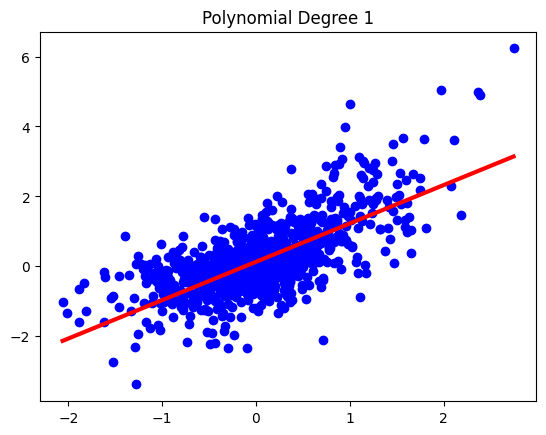

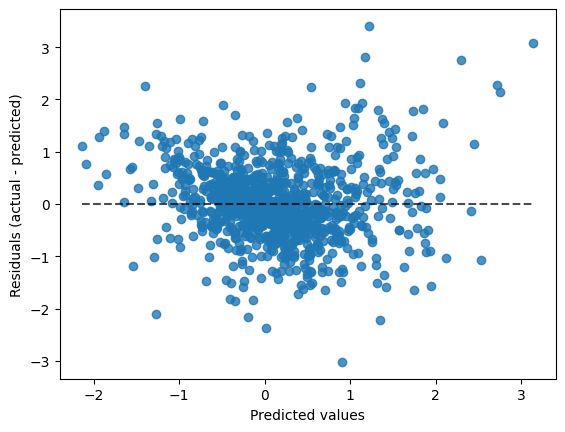

Degree 2 - Coefficients:  [[0.         0.96092434 0.33114272]]
Degree 2 - Intercept:  [0.0107398]
Degree 2 - Score:  0.5291213141898793


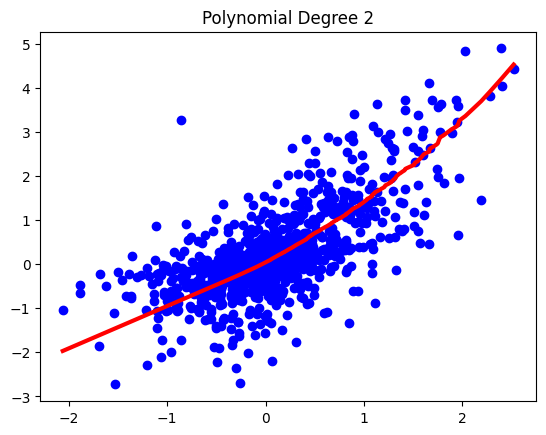

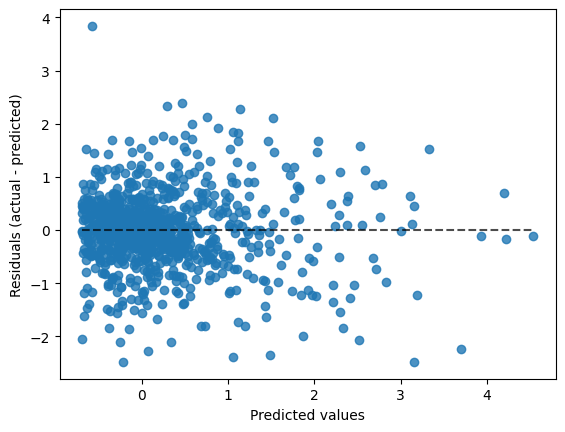

Degree 3 - Coefficients:  [[0.         0.88302119 0.29588553 0.04725917]]
Degree 3 - Intercept:  [0.0227393]
Degree 3 - Score:  0.5581798152958644


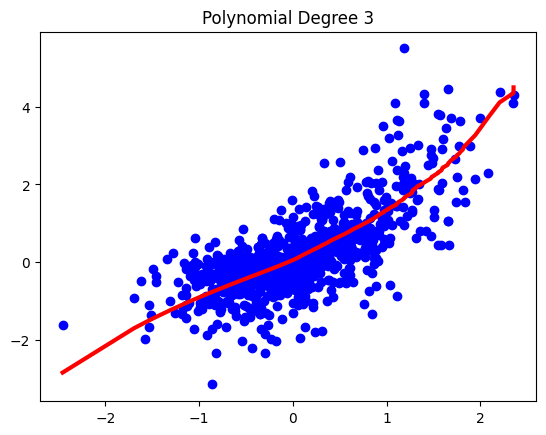

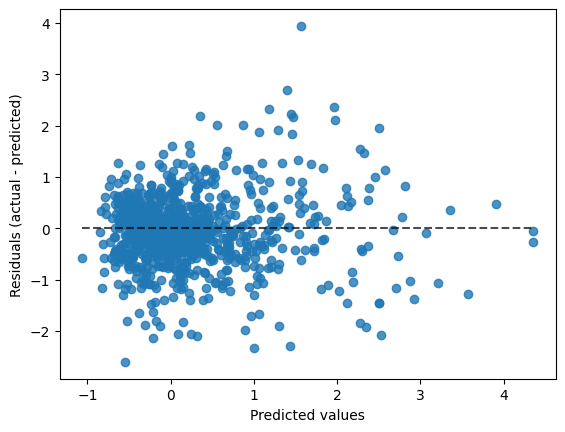

Degree 4 - Coefficients:  [[ 0.          0.84650316  0.3681178   0.07516609 -0.02402508]]
Degree 4 - Intercept:  [-0.00045092]
Degree 4 - Score:  0.5394687796698333


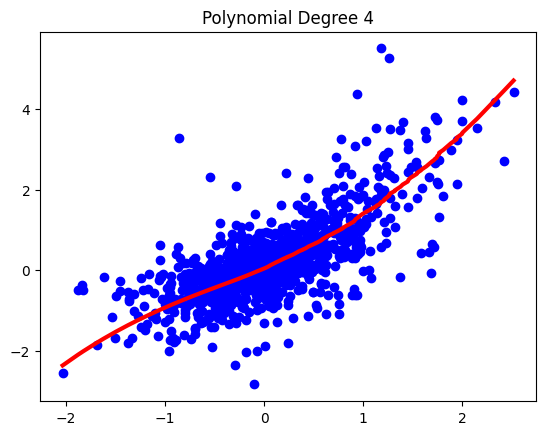

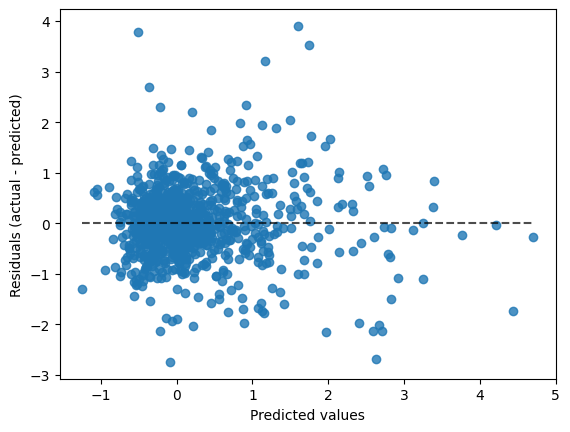

Degree 5 - Coefficients:  [[ 0.          0.86899008  0.40191671  0.05923159 -0.03829352  0.00418859]]
Degree 5 - Intercept:  [0.00259991]
Degree 5 - Score:  0.5319781197392444


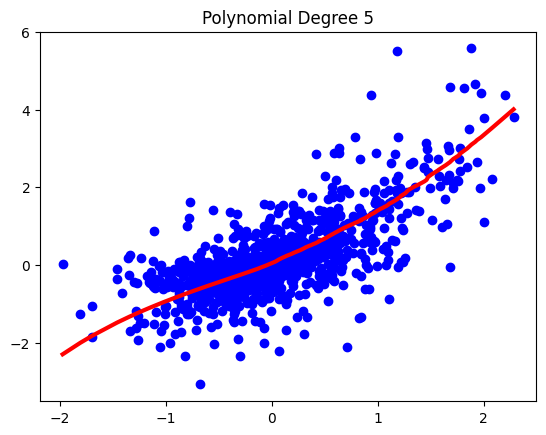

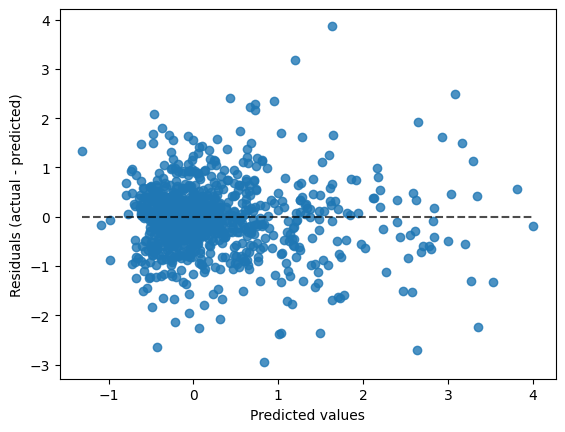

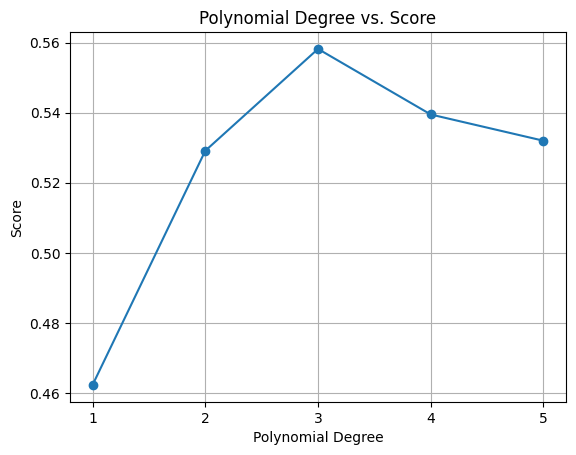

In [ ]:
# Making a for loop to try different polynomial degrees
# This regenerates the test set each time, but I've run it several tims and the degree 3 polynomial seems to be the best fit in general
degree_max = 5 # this maximum is probably excessive, I would expect degree 2-3 at most
polynomial_scores = np.zeros([2,degree_max])
for degree in range(1, degree_max + 1):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2)
    poly_regr = LinearRegression()
    poly_regr.fit(X_train_poly, y_train_poly)
    print(f"Degree {degree} - Coefficients: ", poly_regr.coef_)
    print(f"Degree {degree} - Intercept: ", poly_regr.intercept_)
    print(f"Degree {degree} - Score: ", poly_regr.score(X_test_poly, y_test_poly))
    
    score_index = degree - 1
    polynomial_scores[0, score_index] = degree
    polynomial_scores[1, score_index] = poly_regr.score(X_test_poly, y_test_poly)

    X_test_poly_sorted = np.sort(X_test_poly, axis=0)
    y_pred_poly = poly_regr.predict(X_test_poly)
    y_pred_poly_sorted = poly_regr.predict(X_test_poly_sorted)
    
    plt.scatter(X_test_poly[:,1], y_test_poly, color='blue')
    plt.plot(X_test_poly_sorted[:,1], y_pred_poly_sorted, color='red', linewidth=3)
    plt.title(f"Polynomial Degree {degree}")
    plt.show()
    
    display = PredictionErrorDisplay(y_true=y_test_poly, y_pred=y_pred_poly)
    display.plot()
    plt.show()
# Plotting the polynomial scores
plt.plot(polynomial_scores[0], polynomial_scores[1], marker='o')
plt.title("Polynomial Degree vs. Score")
plt.xlabel("Polynomial Degree")
plt.ylabel("Score")
plt.xticks(np.arange(1, degree_max + 1))
plt.grid()
plt.show()

In [ ]:
# Trying a cubic fit
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)
X_train_poly3, X_test_poly3, y_train_poly3, y_test_poly3 = train_test_split(X_poly3, y, test_size=0.2)
poly_regr3 = LinearRegression()
poly_regr3.fit(X_train_poly3, y_train_poly3)
print("Coefficients: ", poly_regr3.coef_)
print("Intercept: ", poly_regr3.intercept_)
print(poly_regr3.score(X_test_poly3, y_test_poly3))

Coefficients:  [[0.         0.90160164 0.29563843 0.04958299]]
Intercept:  [0.0027673]
0.516916313404246


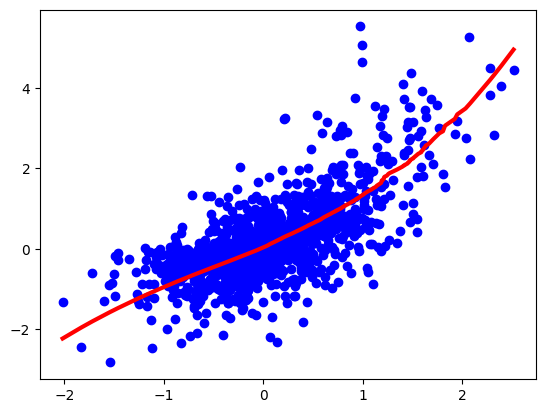

In [66]:
X_test_poly_sorted3 = np.sort(X_test_poly3, axis=0)
y_pred_poly3 = poly_regr3.predict(X_test_poly3)
y_pred_poly_sorted3 = poly_regr3.predict(X_test_poly_sorted3)
plt.scatter(X_test_poly3[:,1], y_test_poly3, color='blue')
plt.plot(X_test_poly_sorted3[:,1], y_pred_poly_sorted3, color='red', linewidth=3)

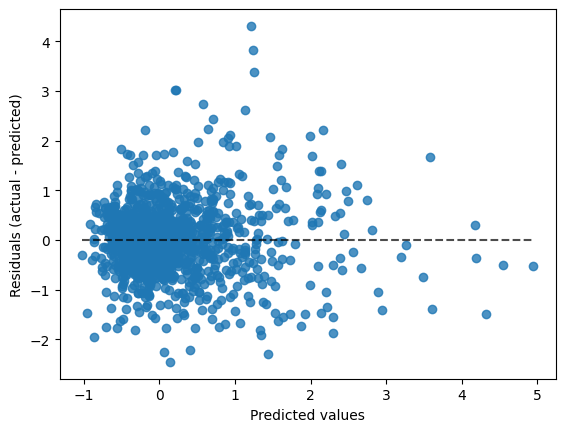

In [67]:
display = PredictionErrorDisplay(y_true=y_test_poly3, y_pred=y_pred_poly3)
display.plot()
plt.show()

In the plots above, there are some very obvious outliers in the cubic polynomial test set that I believe are due to players being traded midseason; it uses the full season WPA but two separate partial season WAR totals.

# Translating findings to WAR

I plan to replace WAA with WPA in the WAR calculation for each reliever to get an adjusted WAR. Next, I'll combine these results with the WAR values for starting pitchers and batters for each team. With this data, I'll compare the two versions of WAR to see which correlates better with team records.

# Challenges

I have to check how the data handles pitchers batting- it includes NL data from before the universal DH. I think batting WAR and pitching WAR are computed separately, since they had to consider this with Ohtani. I also have to check to see if players' separate stints with each team are handled differently. Finally, I'm not sure why the two files have different WAR totals for some players- what's going on there? Also, what about pitcher fielding?

# Other notes
From looking at player pages, I determined that WAR_x is bWAR, and WAR_y is fWAR. I might look at different combinations of WAR (BRef, FG, or my adjusted one for relievers) to see what is more consistent with team wins. Among starters, hitters, and relievers, this leads to 12 possible combinations.

In [53]:
combined_pitching_data.shape

(7666, 62)

In [54]:
combined_pitching_data[['name_common','year_ID','WAA','bWAR','fWAR','WPA']].head(10)

,name_common,year_ID,WAA,bWAR,fWAR,WPA
2587,Zack Britton,2016,2.7048,4.14,2.5,6.33
7122,Emmanuel Clase,2024,2.7454,4.44,2.2,6.23
3794,Blake Treinen,2018,2.4480,4.37,3.6,6.22
3402,Kenley Jansen,2017,1.8850,2.98,3.4,5.57
2471,Mark Melancon,2015,0.9750,1.84,1.4,5.52
4649,Will Smith,2019,1.1844,2.25,1.2,5.50
908,Jim Johnson,2012,1.2638,2.35,1.2,5.27
650,Tyler Clippard,2011,2.0736,3.36,1.5,5.26
2702,Andrew Miller,2016,1.4696,2.34,2.9,5.07
2703,Andrew Miller,2016,0.9958,1.40,2.9,5.07


# Problem to resolve

It looks like Baseball Reference and Fangraphs handle cases where a player was traded midseason differently from each other. The bWAR data is split into the two stints, while fWAR and WPA represent the full season. Maybe I could resolve this by using fWAR instead of bWAR as the base later on?

Update: Using fWAR instead of bWAR introduces other problems. I might have to look for a split in WPA or another way to handle it (split proportionally? Not perfect because usage could change). I'm not sure there's really a good and accurate way to do this.

In [103]:
# add a column for the adjusted WAR for relievers using bWAR
combined_pitching_data.insert(combined_pitching_data.shape[1], 'pWAR', combined_pitching_data['bWAR'] + combined_pitching_data['WPA'] - combined_pitching_data['WAA'])
#combined_pitching_data.insert(combined_pitching_data.shape[1], 'prob_bWAR', combined_pitching_data['bWAR'] + combined_pitching_data['WPA'] - combined_pitching_data['WAA'])
# add a column for the adjusted WAR for relievers using fWAR
# maybe don't do this because WAA is not available for fWAR
#combined_pitching_data.insert(combined_pitching_data.shape[1], 'prob_fWAR', combined_pitching_data['fWAR'] + combined_pitching_data['WPA'] - combined_pitching_data['WAA'])

In [105]:
combined_pitching_data[['name_common','team_ID','year_ID','G_x','WAA','bWAR','fWAR','pWAR','WPA']].head(10)

,name_common,team_ID,year_ID,G_x,WAA,bWAR,fWAR,pWAR,WPA
2587,Zack Britton,BAL,2016,69,2.7048,4.14,2.5,7.7652,6.33
7122,Emmanuel Clase,CLE,2024,74,2.7454,4.44,2.2,7.9246,6.23
3794,Blake Treinen,OAK,2018,68,2.4480,4.37,3.6,8.1420,6.22
3402,Kenley Jansen,LAD,2017,65,1.8850,2.98,3.4,6.6650,5.57
2471,Mark Melancon,PIT,2015,78,0.9750,1.84,1.4,6.3850,5.52
4649,Will Smith,SFG,2019,63,1.1844,2.25,1.2,6.5656,5.50
908,Jim Johnson,BAL,2012,71,1.2638,2.35,1.2,6.3562,5.27
650,Tyler Clippard,WSN,2011,72,2.0736,3.36,1.5,6.5464,5.26
2702,Andrew Miller,NYY,2016,44,1.4696,2.34,2.9,5.9404,5.07
2703,Andrew Miller,CLE,2016,26,0.9958,1.40,2.9,5.4742,5.07


In [110]:
combined_pitching_data.insert(combined_pitching_data.shape[1], 'WPA_scaled', combined_pitching_data['WPA']) # initializes the scaled version as the original pWAR so it doesn't change if a player played for one team

In [111]:
combined_pitching_data_copy = combined_pitching_data.copy()

In [112]:
# Loop to scale the pWAR values for players who played for multiple teams in a season
for name in combined_pitching_data['name_common'].unique():
    for year in combined_pitching_data['year_ID'].unique():
        player_data = combined_pitching_data[(combined_pitching_data['name_common'] == name) & (combined_pitching_data['year_ID'] == year)]
        if len(player_data) > 1:
            # Scale the pWAR values by the number of games played for each team that year
            total_player_games = sum(player_data['G_x'])
            for team in player_data['team_ID'].unique():
                # Scale the pWAR values for each team
                team_games = player_data.loc[player_data['team_ID'] == team, 'G_x'].values[0]
                team_wpa = player_data.loc[player_data['team_ID'] == team, 'WPA'].values[0]
                combined_pitching_data.loc[(combined_pitching_data['name_common'] == name) & (combined_pitching_data['year_ID'] == year) & (combined_pitching_data['team_ID'] == team), 'WPA_scaled'] = team_wpa*team_games/total_player_games

In [115]:
combined_pitching_data.head(10)

,name_common,age,mlb_ID,player_ID,year_ID,team_ID,stint_ID,lg_ID,G_x,GS_x,...,-WPA,RE24,REW,WPA/LI,fWAR,G_y,GS_y,pWAR,pWAR_scaled,WPA_scaled
2587,Zack Britton,28.0,502154.0,brittza01,2016,BAL,1,AL,69,0,...,-3.63,30.89,3.13,2.57,2.5,69,0,7.7652,7.765200,6.330000
7122,Emmanuel Clase,26.0,661403.0,claseem01,2024,CLE,1,AL,74,0,...,-4.19,30.26,3.18,2.97,2.2,74,0,7.9246,7.924600,6.230000
3794,Blake Treinen,30.0,595014.0,treinbl01,2018,OAK,1,AL,68,0,...,-7.45,27.11,2.78,2.57,3.6,68,0,8.1420,8.142000,6.220000
3402,Kenley Jansen,29.0,445276.0,janseke01,2017,LAD,1,NL,65,0,...,-3.94,22.20,2.27,2.45,3.4,65,0,6.6650,6.665000,5.570000
2471,Mark Melancon,30.0,453343.0,melanma01,2015,PIT,1,NL,78,0,...,-6.12,16.44,1.75,1.95,1.4,78,0,6.3850,6.385000,5.520000
4649,Will Smith,29.0,519293.0,smithwi04,2019,SFG,1,NL,63,0,...,-5.14,15.07,1.56,1.62,1.2,63,0,6.5656,6.565600,5.500000
908,Jim Johnson,29.0,462382.0,johnsji04,2012,BAL,1,AL,71,0,...,-5.67,12.49,1.29,2.15,1.2,71,0,6.3562,6.356200,5.270000
650,Tyler Clippard,26.0,461325.0,clippty01,2011,WSN,1,NL,72,0,...,-5.42,28.18,3.06,1.93,1.5,72,0,6.5464,6.546400,5.260000
2702,Andrew Miller,31.0,453192.0,millean01,2016,NYY,1,AL,44,0,...,-4.84,24.82,2.50,2.71,2.9,70,0,5.9404,4.057257,3.186857
2703,Andrew Miller,31.0,453192.0,millean01,2016,CLE,2,AL,26,0,...,-4.84,24.82,2.50,2.71,2.9,70,0,5.4742,2.287343,1.883143


In [114]:
combined_pitching_data['pWAR_scaled'] = combined_pitching_data['bWAR'] + combined_pitching_data['WPA_scaled'] - combined_pitching_data['WAA']

In [116]:
pitching_data_cle_2024 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'CLE') & (combined_pitching_data['year_ID'] == 2024)]
print(pitching_data_cle_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']].head(10))
print(f"Difference in wins in 2024: {sum(pitching_data_cle_2024['pWAR_scaled'])-sum(pitching_data_cle_2024['bWAR'])}")

pitching_data_cle_2023 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'CLE') & (combined_pitching_data['year_ID'] == 2023)]
print(pitching_data_cle_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']].head(10))
print(f"Difference in wins in 2023: {sum(pitching_data_cle_2023['pWAR_scaled'])-sum(pitching_data_cle_2023['bWAR'])}")

         name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  WPA_scaled
7122  Emmanuel Clase     CLE     2024  4.44   2.2       7.9246        6.23
7315      Cade Smith     CLE     2024  2.41   2.7       3.6802        2.95
7162   Hunter Gaddis     CLE     2024  2.61   1.6       3.2608        2.32
7190      Tim Herrin     CLE     2024  1.74   1.0       2.1250        1.60
7185     Sam Hentges     CLE     2024  0.37   0.3       0.8075        0.63
7082     Pedro Avila     CLE     2024  0.63   0.2       1.0600        0.51
7296  Erik Sabrowski     CLE     2024  0.60   0.4       0.3500        0.35
7257      Eli Morgan     CLE     2024  1.09   0.3       0.6036        0.32
7297    Nick Sandlin     CLE     2024 -0.06  -0.7       0.6192        0.21
7085    Scott Barlow     CLE     2024  0.19   0.0       0.6205        0.21
Difference in wins in 2024: 7.380800000000001
              name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  \
6672           Matt Moore     CLE     2023  0.07   0.6    

In [117]:
pitching_data_min_2024 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'MIN') & (combined_pitching_data['year_ID'] == 2024)]
print(pitching_data_min_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']])
print(f"Difference in wins in 2024: {sum(pitching_data_min_2024['pWAR_scaled'])-sum(pitching_data_min_2024['bWAR'])}")

pitching_data_min_2023 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'MIN') & (combined_pitching_data['year_ID'] == 2023)]
print(pitching_data_min_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']])
print(f"Difference in wins in 2023: {sum(pitching_data_min_2023['pWAR_scaled'])-sum(pitching_data_min_2023['bWAR'])}")

          name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  WPA_scaled
7203      Griffin Jax     MIN     2024  2.78   2.6     3.218800    2.030000
7144      Jhoan Durán     MIN     2024  0.17   1.2     1.874000    1.530000
7074     Jorge Alcalá     MIN     2024  1.35   0.3     1.577800    1.000000
7325    Brock Stewart     MIN     2024 -0.08   0.1     0.898000    0.810000
7100      Matt Bowman     MIN     2024  0.22  -0.2     0.162000    0.110000
7097    Scott Blewett     MIN     2024  0.80   0.1     0.486000    0.400000
7323    Josh Staumont     MIN     2024  0.21   0.2     0.327500    0.140000
7114   Diego Castillo     MIN     2024  0.21   0.0    -0.002600    0.010000
7351     Matt Wallner     MIN     2024  0.05   0.0    -0.022500    0.000000
7153      Kyle Farmer     MIN     2024 -0.02   0.0     0.079900    0.000000
7115     Willi Castro     MIN     2024  0.05   0.0    -0.020000    0.000000
7298       Cole Sands     MIN     2024  1.25   1.5     0.526600   -0.060000
7140     Ran

In [118]:
pitching_data_kcr_2024 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'KCR') & (combined_pitching_data['year_ID'] == 2024)]
print(pitching_data_kcr_2024[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']])
print(f"Difference in wins in 2024: {sum(pitching_data_kcr_2024['pWAR_scaled'])-sum(pitching_data_kcr_2024['bWAR'])}")

pitching_data_kcr_2023 = combined_pitching_data[(combined_pitching_data['team_ID'] == 'KCR') & (combined_pitching_data['year_ID'] == 2023)]
print(pitching_data_kcr_2023[['name_common','team_ID','year_ID','bWAR','fWAR','pWAR_scaled','WPA_scaled']])
print(f"Difference in wins in 2023: {sum(pitching_data_kcr_2023['pWAR_scaled'])-sum(pitching_data_kcr_2023['bWAR'])}")

            name_common team_ID  year_ID  bWAR  fWAR  pWAR_scaled  WPA_scaled
7305     John Schreiber     KCR     2024  0.48   1.1     1.885100    1.470000
7149        Lucas Erceg     KCR     2024  0.79   1.7     0.759761    0.388361
7105         Kris Bubic     KCR     2024  0.78   0.9     0.689400    0.390000
7180      Hunter Harvey     KCR     2024 -0.17   0.7     0.004992    0.019592
7307        Colin Selby     KCR     2024 -0.06   0.0     0.123600    0.032000
7131        Steven Cruz     KCR     2024  0.24   0.1    -0.018500    0.060000
7230           Sam Long     KCR     2024  0.69   0.2     0.381700    0.040000
7268  Walter Pennington     KCR     2024  0.03   0.0    -0.004550    0.001250
7234       Jordan Lyles     KCR     2024  0.17   0.0    -0.081500    0.010000
7275        Nick Pratto     KCR     2024  0.04   0.0    -0.019400    0.000000
7229        Nick Loftin     KCR     2024  0.04   0.0    -0.019600    0.000000
7178    Garrett Hampson     KCR     2024  0.04   0.0    -0.02300

# This is one data point, but...

The difference between the results for the Royals and Guardians almost perfectly matches their actual separation in the standings, which is notable because their Pythagorean records were nearly identical (Royals 91-71, Guardiants 90-71). Given that WAR is closely tied to runs, it's worth looking into more combinations of teams.

# Additional steps

Use the regression (quadratic or higher-degree polynomial) to improve predictions for future years based on players' projected WAR from season to season. WPA seems to be pretty volatile year-to-year, but the regression can provide a starting point. It can also account for a pitcher's projected usage changing- for example, if a player moves teams and no longer ranks the same in their new bullpen's hierarchy.

# Other ideas

Explore using teammates' skill levels as a model parameter. The idea is that this can affect how often a reliever is used in high-leverage situations.

Lower the innings threshold to be included in the data sets, especially as team WAR is concerned. I'll have to see what it does to the regression results with a lower or higher cutoff.

In [119]:
# The Marlins have two separate abbreviations because of the name change from Florida to Miami but this shouldn't be an issue for the data set
team_abbr_list = combined_pitching_data['team_ID'].unique()
print(team_abbr_list)

['BAL' 'CLE' 'OAK' 'LAD' 'PIT' 'SFG' 'WSN' 'NYY' 'MIL' 'TBR' 'MIA' 'COL'
 'KCR' 'ATL' 'SDP' 'SEA' 'MIN' 'BOS' 'TEX' 'CIN' 'STL' 'DET' 'ARI' 'TOR'
 'CHW' 'HOU' 'CHC' 'LAA' 'NYM' 'PHI' 'FLA']


In [120]:
year_list = range(start_year, end_year + 1)
war_adjustments = pd.DataFrame(columns=team_abbr_list)

In [121]:
# adjust to fix syntax to get the new row in
for year in year_list:
    year_data = combined_pitching_data[combined_pitching_data['year_ID'] == year]
    team_war_adjustments = {}
    for team in team_abbr_list:
        team_data = year_data[year_data['team_ID'] == team]
        if not team_data.empty:
            team_war_adjustments[team] = sum(team_data['pWAR_scaled']) - sum(team_data['bWAR'])
        else:
            team_war_adjustments[team] = 0
    war_adjustments = pd.concat([war_adjustments, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)
print(war_adjustments)

/var/folders/l9/rl78x5z50p1fdvqxvwl18w8r0000gn/T/ipykernel_38631/1885311255.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  war_adjustments = pd.concat([war_adjustments, pd.DataFrame(team_war_adjustments, index=[year])], ignore_index=False)


           BAL       CLE       OAK       LAD       PIT       SFG       WSN  \
2010 -0.236400  3.824914  2.317229 -0.036100 -0.486123  0.808527 -0.760592   
2011  0.602813  4.097300  1.694273  1.871600  1.325700  5.855300  2.452900   
2012  5.528524  1.955948  2.195433 -1.319619  3.379169  5.062238  0.186700   
2013  3.037599  3.617667  1.246900  3.455880  6.633930 -2.072600  2.415142   
2014  6.364507  1.925969 -0.296581  1.625900  4.144397  1.174283  2.478900   
2015  3.660142 -0.828200 -2.705301  1.599528  9.769639  1.681358  0.213210   
2016  5.846781  5.330088 -3.234982  2.267118  1.224141  1.755694 -1.826200   
2017  2.377200  3.619880 -2.979657  5.278693 -0.298024 -2.535434  4.250651   
2018 -0.814884  3.158106  6.693013  2.391571  3.625970  4.382168 -1.834589   
2019 -1.404996  4.246125  1.356998  2.374050  0.426557  7.142755 -1.531682   
2020 -3.699858  3.463100  2.577900  1.047400  0.775856 -0.504800  0.811300   
2021  0.063775  1.214208  0.509918  5.102953  3.037479  5.220653

In [63]:
print(war_adjustments[['FLA','MIA']])

         FLA     MIA
2010 -2.7899       0
2011 -4.5949       0
2012  0.0000  0.4062
2013  0.0000  0.9398
2014  0.0000 -1.2229
2015  0.0000  -0.099
2016  0.0000  2.1704
2017  0.0000  5.9531
2018  0.0000   3.328
2019  0.0000  1.5352
2020  0.0000  1.7096
2021  0.0000 -1.0441
2022  0.0000 -3.9657
2023  0.0000  5.2327
2024  0.0000 -0.9235
